# Sportsbook Odds EDA (Alfie Data)

**Category:** sports / exploratory  \n**Created:** 2026-02-09  \n**Author:** Codex

---

## Key Findings

- Dataset has 28,517 bookmaker quotes across 4,152 games and 15 bookmakers; game dates range 2021-10-03 to 2026-04-01.
- Typical odds (p5-p95): home 1.12-4.33 (median 1.65), away 1.22-6.75 (median 2.30). Extremes reach 1.01/14.00 home and 1.03/18.00 away.
- Home team is the favorite (lower odds) in 63.9% of quotes, suggesting a mild home-favorite skew.
- Average overround is 4.6% (median 4.5%, p5-p95 2.8%-6.7%).
- Bookmaker margins differ: lowest average overrounds are ['BetVictor', 'Betano.uk', '10bet'] (~3.9% avg), while highest are ['AllBritishCasino', 'BetUK', 'SpreadEX'] (~6.6% avg).


**Key Findings Notes**
- Dataset coverage shows we have enough volume across multiple bookmakers to compare pricing behavior without modeling.
- Odds ranges highlight the typical competitiveness of matchups; extremes flag mismatches or potentially stale lines worth checking.
- Home-favorite skew suggests the market consistently prices home advantage; this can be a control variable in later analyses.
- Overround summary quantifies the average bookmaker margin; useful baseline for comparing markets and later combining with Polymarket data.
- Margin differences by bookmaker indicate pricing strategy differences; helps pick which books to focus on in combined reporting.


## Setup & Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')


## Load Data


In [2]:
matches = pd.read_csv('data/alfie data/sportsbook_matches.csv', parse_dates=['game_date', 'commence_time'])
odds = pd.read_csv('data/alfie data/sportsbook_odds.csv')

# Ensure numeric odds
for col in ['home_odds', 'away_odds']:
    odds = odds[pd.to_numeric(odds[col], errors='coerce').notna()]
    odds[col] = odds[col].astype(float)

df = odds.merge(matches, on='external_id', how='left')

# Derived metrics
df['implied_home_prob'] = 1 / df['home_odds']
df['implied_away_prob'] = 1 / df['away_odds']
df['overround'] = df['implied_home_prob'] + df['implied_away_prob'] - 1
df['home_favorite'] = df['home_odds'] < df['away_odds']

df.head()


,external_id,bookmaker,home_odds,away_odds,game_date,home_team_abbr,away_team_abbr,commence_time,implied_home_prob,implied_away_prob,overround,home_favorite
0,nba_20260401_dal_mil,10bet,1.70,2.20,2026-04-01,MIL,DAL,2026-04-01,0.588235,0.454545,0.042781,True
1,nba_20260401_dal_mil,7Bet,1.71,2.20,2026-04-01,MIL,DAL,2026-04-01,0.584795,0.454545,0.039341,True
2,nba_20260401_dal_mil,AllBritishCasino,1.66,2.15,2026-04-01,MIL,DAL,2026-04-01,0.602410,0.465116,0.067526,True
3,nba_20260401_dal_mil,bet365,1.71,2.20,2026-04-01,MIL,DAL,2026-04-01,0.584795,0.454545,0.039341,True
4,nba_20260401_dal_mil,Betano.uk,1.68,2.15,2026-04-01,MIL,DAL,2026-04-01,0.595238,0.465116,0.060354,True


## Data Overview


In [3]:
summary = {
    'rows': len(df),
    'games': df['external_id'].nunique(),
    'bookmakers': df['bookmaker'].nunique(),
    'game_date_min': df['game_date'].min(),
    'game_date_max': df['game_date'].max(),
    'missing_commence_time': df['commence_time'].isna().mean(),
}
summary


{'rows': 28517,
 'games': 4152,
 'bookmakers': 15,
 'game_date_min': Timestamp('2021-10-03 00:00:00'),
 'game_date_max': Timestamp('2026-04-01 00:00:00'),
 'missing_commence_time': 0.0}

## Visualizations

### Odds Distributions


**What this shows**: The histogram reveals the typical range of home and away decimal odds, with tails indicating heavy favorites/underdogs.
**Why it matters**: Gives a quick sense of market competitiveness and helps identify outlier games that may warrant separate treatment.
**How we can use it**: Use the p5-p95 range as a default filter for summary tables and to avoid distortion from extreme odds.


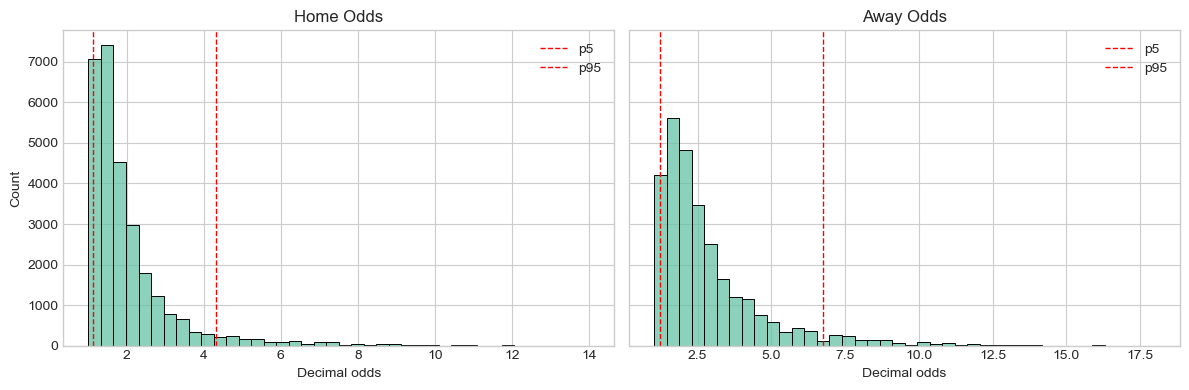

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col, title in zip(axes, ['home_odds', 'away_odds'], ['Home Odds', 'Away Odds']):
    sns.histplot(df[col], bins=40, ax=ax, kde=False)
    ax.axvline(df[col].quantile(0.05), color='red', linestyle='--', linewidth=1, label='p5')
    ax.axvline(df[col].quantile(0.95), color='red', linestyle='--', linewidth=1, label='p95')
    ax.set_title(title)
    ax.set_xlabel('Decimal odds')
    ax.legend()

plt.tight_layout()
plt.show()


### Bookmaker Comparison (Top Volume)


**What this shows**: Side-by-side odds distributions by bookmaker for the most active books.
**Why it matters**: Highlights systematic pricing differences (tighter vs wider odds) across books.
**How we can use it**: Focus combined reporting on a small set of high-volume books or flag books with consistently higher margins.


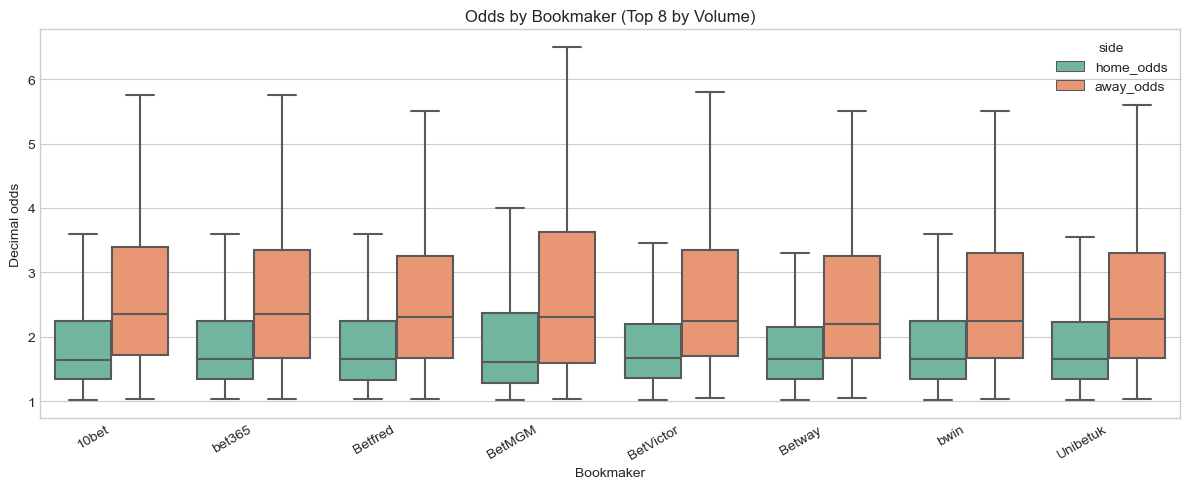

In [5]:
top_bm = df['bookmaker'].value_counts().head(8).index
plot_df = df[df['bookmaker'].isin(top_bm)].copy()

long_df = plot_df.melt(
    id_vars=['bookmaker'],
    value_vars=['home_odds', 'away_odds'],
    var_name='side',
    value_name='odds'
)

plt.figure(figsize=(12, 5))
sns.boxplot(data=long_df, x='bookmaker', y='odds', hue='side', showfliers=False)
plt.title('Odds by Bookmaker (Top 8 by Volume)')
plt.xlabel('Bookmaker')
plt.ylabel('Decimal odds')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Overround Analysis


**What this shows**: Distribution of bookmaker margins and average margin by bookmaker.
**Why it matters**: Quantifies the house take and shows which books are more expensive to bet through.
**How we can use it**: Establish a benchmark margin for sportsbook odds before comparing to prediction markets.


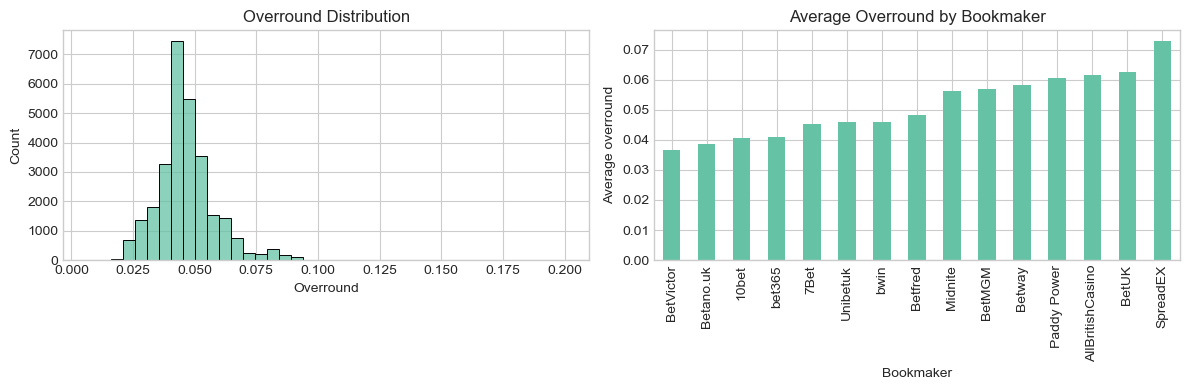

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['overround'], bins=40, ax=axes[0])
axes[0].set_title('Overround Distribution')
axes[0].set_xlabel('Overround')

ov_by_bm = df.groupby('bookmaker')['overround'].mean().sort_values()
ov_by_bm.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Overround by Bookmaker')
axes[1].set_xlabel('Bookmaker')
axes[1].set_ylabel('Average overround')

plt.tight_layout()
plt.show()


### Home vs Away Favorite Bias


**What this shows**: Share of quotes where the home team is priced as the favorite.
**Why it matters**: Indicates consistent home-advantage pricing that may affect combined market comparisons.
**How we can use it**: Use as a descriptive control when we align sportsbook odds with other markets.


In [7]:
home_fav_rate = df['home_favorite'].mean()
home_fav_rate


0.6388470035417471

### Time Patterns (By Game Date)

Note: the dataset has one odds snapshot per game-bookmaker with no collection timestamp, so we can only examine variation by game date (not how odds move as kickoff approaches).


**What this shows**: Average overround and implied home probability by game month.
**Why it matters**: Captures broad seasonal changes in pricing (if any), even without true snapshot timestamps.
**How we can use it**: Helps decide if we should stratify analysis by season/month in the combined report.


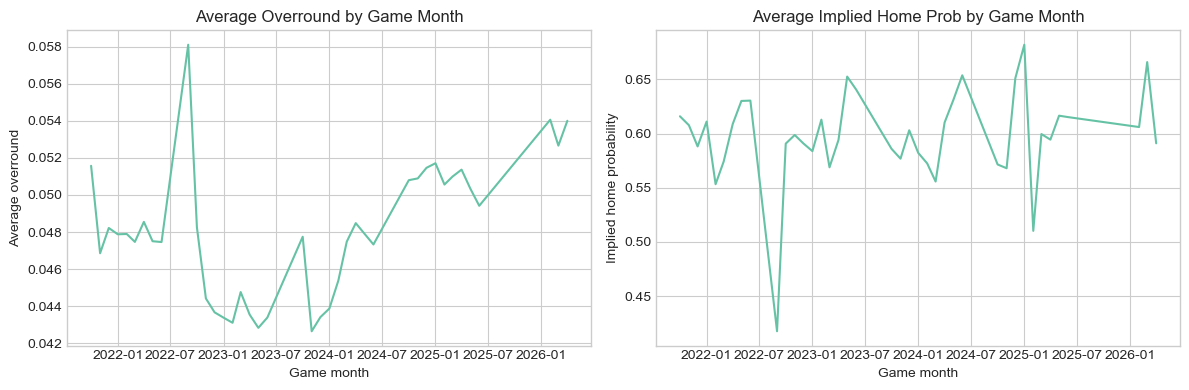

In [8]:
df['game_month'] = df['game_date'].dt.to_period('M').dt.to_timestamp()
monthly = df.groupby('game_month')[['overround', 'implied_home_prob']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=monthly, x='game_month', y='overround', ax=axes[0])
axes[0].set_title('Average Overround by Game Month')
axes[0].set_xlabel('Game month')
axes[0].set_ylabel('Average overround')

sns.lineplot(data=monthly, x='game_month', y='implied_home_prob', ax=axes[1])
axes[1].set_title('Average Implied Home Prob by Game Month')
axes[1].set_xlabel('Game month')
axes[1].set_ylabel('Implied home probability')

plt.tight_layout()
plt.show()


## Intuition
- Home-favorite skew could reflect real home-court advantage plus pricing conservatism.
- Overrounds clustering around ~3-7% is consistent with standard sportsbook margins; higher-margin books may target convenience or lower-liquidity bettors.
- Bookmaker-to-bookmaker differences likely reflect market position, regional regulation, and differing risk tolerance.
- Fat-tailed odds (very short or very long) are expected in mismatched games; extremes may also indicate stale or low-confidence lines.


## Questions for Team
- Do we have timestamps for when odds were collected? If not, can Alfie provide snapshot time(s) to analyze movement toward kickoff?
- Should we normalize bookmaker comparison by league/season, or is this dataset all NBA?
- Any preference on focusing bookmaker comparisons on a short list (e.g., top 5 by volume) for the combined report?
- Are there filters we should apply (e.g., exclude odds above 10 or below 1.05) for downstream summaries?
